# Analyze A/B Test Results

This project will ensure you have mastered the subjects covered in the Hypothesis Testing lessons.  The hope is to have this project be as comprehensive of these topics as possible.  Good luck!

Corresponding with this notebook is a slide deck where you will need to update all the portions in red.  Completing the notebook will provide all the results needed for the slides.  **Correctly completing the slides is a required part of the project.**

## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Probability](#probability)
- [Part III - Experimentation](#experimentation)


<a id='intro'></a>
### Introduction

A/B tests are very commonly performed by data analysts and data scientists.  For this project, you will be working to understand the results of an A/B test run by an e-commerce website.  Your goal is to work through this notebook to help the company understand if they should implement the new page, keep the old page, or perhaps run the experiment longer to make their decision.

**As you work through this notebook, follow along in the classroom and answer the corresponding quiz questions associated with each question.** The labels for each classroom concept are provided for each question.  This will assure you are on the right track as you work through the project, and you can feel more confident in your final submission meeting the criteria.  As a final check, assure you meet all the criteria on the rubric.

<a id='descriptive'></a>
#### Part I - Descriptive Statistics

To get started, let's import our libraries.

In [64]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from math import erf, sqrt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

random.seed(0) 
np.random.seed(0)

def subgroup_probability(dataframe, column, value):
    """Return the proportion of rows where a column matches a target value."""
    return (dataframe[column] == value).mean()

def subgroup_conversion_rate(dataframe, **filters):
    """Return the conversion rate for a subgroup defined by exact-match filters."""
    subgroup = dataframe.copy()
    for column, value in filters.items():
        subgroup = subgroup[subgroup[column] == value]
    return subgroup['converted'].mean()

def simulate_binary_outcomes(sample_size, success_rate, seed):
    """Simulate Bernoulli outcomes as a Python list for notebook display cells."""
    rng = np.random.default_rng(seed)
    return rng.binomial(1, success_rate, sample_size).tolist()

def simulate_null_differences(n_treatment, n_control, success_rate, iterations, seed):
    """Simulate treatment-control conversion differences under the null hypothesis."""
    rng = np.random.default_rng(seed)
    return rng.binomial(n_treatment, success_rate, iterations) / n_treatment - rng.binomial(n_control, success_rate, iterations) / n_control

def one_sided_z_test(observed_difference, treatment_successes, control_successes, n_treatment, n_control):
    """Compute the pooled one-sided z-test statistic and p-value for two proportions."""
    pooled_rate = (treatment_successes + control_successes) / (n_treatment + n_control)
    standard_error = np.sqrt(pooled_rate * (1 - pooled_rate) * (1 / n_treatment + 1 / n_control))
    z_statistic = observed_difference / standard_error
    p_value = 1 - 0.5 * (1 + erf(z_statistic / sqrt(2)))
    return z_statistic, p_value
#Ensure to add the random.seed(0) to every cell 
#that includes np.random to ensure consistency 

For all questions in `Part I` notice links to [pandas documentation](https://pandas.pydata.org/) are provided to assist with answering the questions.  Though there are other ways you could solve the questions, the documentation is provided to assist you with one fast way to find the answer to each question.


`a)` Now, read in the `ab_data.csv` data. Store it in `df`. Read in the dataset and take a look at the top few rows here. **This question is completed for you**.

In [65]:
df = pd.read_csv('ab_data.csv')
df.head()

,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0


`b)` Use the below cell to find the number of rows in the dataset. [Helpful pandas link - `Dataframe.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html#pandas.DataFrame.shape)

In [66]:
n_rows = df.shape[0]
n_rows

69889

`c)` The proportion of users converted.  [Helpful  Pandas Link - `Dataframe.mean`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html)

In [67]:
overall_conversion_rate = df['converted'].mean()
overall_conversion_rate

np.float64(0.13047832992316388)

`d)` Do any of the rows have missing values? [Helpful Pandas Link - `Dataframe.isnull`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html) and [Helpful Pandas Link- `Dataframe.sum`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)

In [68]:
missing_by_column = df.isnull().sum()
missing_by_column.to_frame(name='missing_count')

,missing_count
country,0
group,0
converted,0


`e)` How many customers are from each country? Build a bar chart to show the count of visits from each country.

In [69]:
# number of visitors from each country - pull the necessary code from the next cell to provide just the counts
country_counts = df['country'].value_counts().sort_index()
country_counts

country
CA     3488
UK    17551
US    48850
Name: count, dtype: int64

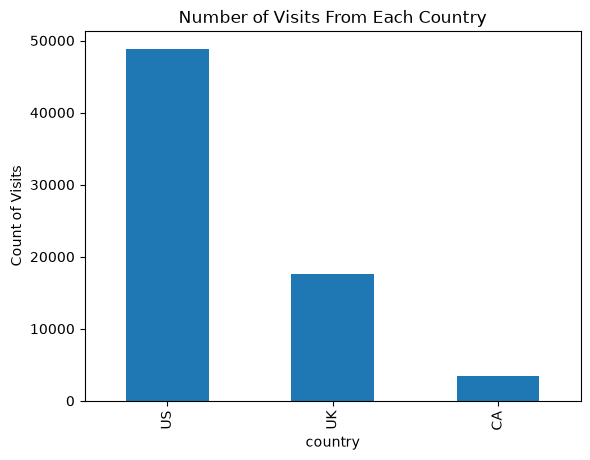

In [70]:
# bar chart of results - this part is done for you
df['country'].value_counts().plot(kind='bar');
plt.title('Number of Visits From Each Country');
plt.ylabel('Count of Visits');
plt.show();

`f)` Recognize that all of your columns are of a **categorical data type** with the exception of one.  Which column is not **categorical**? [Helpful Pandas Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)

In [71]:
df.dtypes

country        str
group          str
converted    int64
dtype: object

`g)` What are the possible values of the `converted` column?  Does it make sense that these values are the only possible values? Why or why not? 

**Here you can use one of the functions you used in an earlier question**.

In [72]:
converted_values = sorted(df['converted'].unique().tolist())
print(converted_values)
print('These values make sense because conversion is binary: 1 means the user converted and 0 means the user did not convert.')

[0, 1]
These values make sense because conversion is binary: 1 means the user converted and 0 means the user did not convert.


<a id='probability'></a>
#### Part II - Probability

Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `converting`.

`a)` What is the probability of an individual converting regardless of the page they receive or the country they are from? Simply, what is the chance of conversion in the dataset?

In [73]:
subgroup_conversion_rate(df)

np.float64(0.13047832992316388)

`b)` Given that an individual was in the `control` group, what is the probability they converted? **This question is completed for you**

In [74]:
subgroup_conversion_rate(df, group='control')

np.float64(0.1052540515600669)

`c)` Given that an individual was in the `treatment` group, what is the probability they converted?

In [75]:
treatment_conversion_rate = subgroup_conversion_rate(df, group='treatment')
treatment_conversion_rate

np.float64(0.15532078043793132)

`d)` Do you see evidence that the treatment is related to higher `converted` rates?

In [76]:
control_conversion_rate = subgroup_conversion_rate(df, group='control')
treatment_conversion_rate = subgroup_conversion_rate(df, group='treatment')
observed_diff = treatment_conversion_rate - control_conversion_rate
print(f'Control conversion rate: {control_conversion_rate:.6f}')
print(f'Treatment conversion rate: {treatment_conversion_rate:.6f}')
print(f'Observed treatment lift: {observed_diff:.6f}')
print('Yes. The treatment group converts at a higher rate than the control group in this dataset.')

Control conversion rate: 0.105254
Treatment conversion rate: 0.155321
Observed treatment lift: 0.050067
Yes. The treatment group converts at a higher rate than the control group in this dataset.


`e)` What is the probability that an individual was in the `treatment`?

In [77]:
subgroup_probability(df, 'group', 'treatment')

np.float64(0.5038131894861853)

`f)` What is the probability that an individual was from Canada `CA`?

In [78]:
subgroup_probability(df, 'country', 'CA')

np.float64(0.04990771079855199)

`g)` Given that an individual was in the `US`, what was the probability that they `converted`? **This question is completed for you**

$P(\text{converted} == 1|\text{country} ==\text{"US"})$



In [79]:
subgroup_conversion_rate(df, country='US')

np.float64(0.13277379733879222)

`h)` Given that an individual was in the `UK`, what was the probability that they `converted`? 

$P(\text{converted} == 1|\text{country} ==\text{"UK"})$

In [80]:
subgroup_conversion_rate(df, country='UK')

np.float64(0.12512107572218106)

`i)` Do you see evidence that the `converted` rate might differ from one country to the next?

In [81]:
country_conversion_rates = df.groupby('country')['converted'].mean().sort_values(ascending=False)
print(country_conversion_rates)
print('The country-level conversion rates are fairly close overall, although the US is modestly higher than the UK and Canada.')

country
US    0.132774
CA    0.125287
UK    0.125121
Name: converted, dtype: float64
The country-level conversion rates are fairly close overall, although the US is modestly higher than the UK and Canada.


`j)` Consider the table below, fill in the conversion rates below to look at how conversion by country and treatment group vary.  The `US` column is done for you, and two methods for calculating the probabilities are shown - **COMPLETE THE REST OF THE TABLE**.  Does it appear that there could be an interaction between how country and treatment impact conversion?

These two values that are filled in can be written as:

$P(\text{converted} == 1|(\text{country} ==\text{"US" AND }\text{group} ==\text{"control"})) = 10.7\%$

$P(\text{converted} == 1|(\text{country} ==\text{"US" AND }\text{group} ==\text{"treatment"})) = 15.8\%$

|             | US          | UK          | CA          |
| ----------- | ----------- | ----------- | ----------- |
| Control     | 10.7%       |  %          |  %          |
| Treatment   | 15.8%       |  %          |  %          |

In [82]:
# Method 1  - explicitly calculate each probability
print(df.query('country == "US" and group == "control" and converted == 1').shape[0]/df.query('country == "US" and group == "control"').shape[0]) 
print(df.query('country == "US" and group == "treatment" and converted == 1').shape[0]/df.query('country == "US" and group == "treatment"').shape[0])

0.10731404958677686
0.1577687626774848


In [83]:
# Method 2 - quickly calculate using `groupby`
df.query('country == "US"').groupby('group')['converted'].mean()

group
control      0.107314
treatment    0.157769
Name: converted, dtype: float64

##### Solution -- Complete the Table Here

|             | US          | UK          | CA          |
| ----------- | ----------- | ----------- | ----------- |
| Control     | 10.7%       | 10.2%       | 9.4%        |
| Treatment   | 15.8%       | 14.9%       | 15.4%       |

group     control  treatment
country                     
CA       0.094474   0.154017
UK       0.101649   0.148698
US       0.107314   0.157769


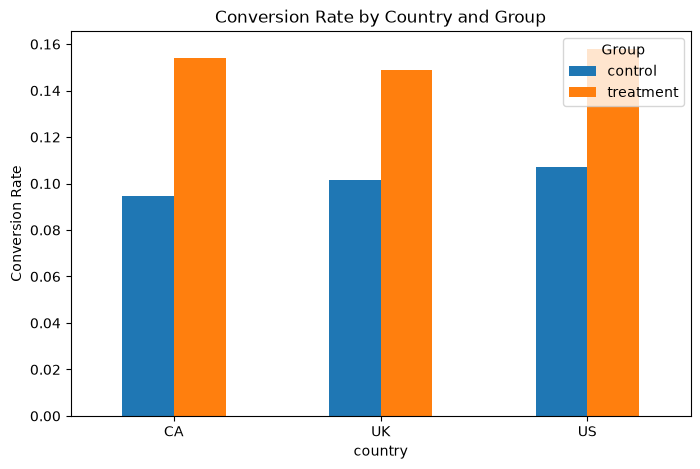

In [84]:
country_group_conversion = df.groupby(['country', 'group'])['converted'].mean().unstack()
print(country_group_conversion)
country_group_conversion.plot(kind='bar', figsize=(8, 5))
plt.title('Conversion Rate by Country and Group')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

<a id='experimentation'></a>
### Part III - Experimentation

Consider you need to make the decision just based on all the data provided.  If you want to assume that the control page is better unless the treatment page proves to be definitely better at a Type I error rate of 5%, you state your null and alternative hypotheses in terms of **$p_{control}$** and **$p_{treatment}$** as:  

$H_{0}: p_{control} >= p_{treatment}$

$H_{1}: p_{control} < p_{treatment}$

Which is equivalent to:

$H_{0}: p_{treatment} - p_{control} <= 0$

$H_{1}: p_{treatment} - p_{control} > 0$


Where  
* **$p_{control}$** is the `converted` rate for the control page
* **$p_{treatment}$** `converted` rate for the treatment page

**Note for this experiment we are not looking at differences associated with country.**

Assume under the null hypothesis, $p_{treatment}$ and $p_{control}$ both have "true" success rates equal to the **converted** success rate regardless of page - that is $p_{treatment}$ and $p_{control}$ are equal. Furthermore, assume they are equal to the **converted** rate in `df` regardless of the page. **These are set in the first cell below.**<br><br>

* Use a sample size for each page equal to the ones in `df`. **These are also set below.**  <br><br>

* Perform the sampling distribution for the difference in `converted` between the two pages over 500 iterations of calculating an estimate from the null.  <br><br>

* Use the cells below to provide the necessary parts of this simulation.  

If this doesn't make complete sense right now, don't worry - you are going to work through the problems below to complete this problem.  You can use **Quiz 4** in the classroom to make sure you are on the right track.<br><br>

`a)` The **convert rate** for $p_{treatment}$ under the null.  The **convert rate** for $p_{control}$ under the null. The sample size for the `control` and the sample size for the `treatment` are from the original dataset. **All of these values are set below, and set the stage for the simulations you will run for the rest of this section.**

In [85]:
p_control_treatment_null  = df['converted'].mean()
p_treatment_null = p_control_treatment_null
p_control_null = p_control_treatment_null
n_treatment = df.query('group == "treatment"').shape[0]
n_control = df.query('group == "control"').shape[0]
observed_diff = subgroup_conversion_rate(df, group='treatment') - subgroup_conversion_rate(df, group='control')
p_treatment_null, p_control_null, n_treatment, n_control, observed_diff

(np.float64(0.13047832992316388),
 np.float64(0.13047832992316388),
 35211,
 34678,
 np.float64(0.050066728877864425))

`b)` Use the results from part `a)` to simulate `n_treatment` transactions with a convert rate of `p_treatment_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **treatment_converted**.  It should look something like the following (the 0's and and 1's **don't** need to be the same): 

`[0, 0, 1, 1, 0, ....]` 

In [86]:
treatment_converted = simulate_binary_outcomes(n_treatment, p_treatment_null, seed=0)
treatment_converted[:10]

[0, 0, 0, 0, 0, 1, 0, 0, 0, 1]

`c)` Use the results from part `a)` to simulate `n_control` transactions with a convert rate of `p_control_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **control_converted**.  It should look something like the following (the 0's and and 1's **don't** need to be exactly the same): 

`[0, 0, 1, 1, 0, ....]` 

In [87]:
control_converted = simulate_binary_outcomes(n_control, p_control_null, seed=1)
control_converted[:10]

[0, 1, 0, 1, 0, 0, 0, 0, 0, 0]

`d)` Find the estimate for $p_{treatment}$ - $p_{control}$ under the null using the simulated values from part `(b)` and `(c)`.

In [88]:
np.mean(treatment_converted) - np.mean(control_converted)

np.float64(-0.0021652818232333892)

`e)` Simulate 500 $p_{treatment}$ - $p_{control}$ values using this same process as `b)`- `d)` above.  Store all 500 values in an numpy array called **p_diffs**.  This array should look similar to the below **(the values will not match AND this will likely take a bit of time to run)**:

`[0.001, -0.003, 0.002, ...]`

In [89]:
p_diffs = simulate_null_differences(n_treatment, n_control, p_treatment_null, iterations=500, seed=0)
p_diffs[:10]

array([ 3.58378407e-03, -1.33125090e-04,  1.24841872e-03, -1.70474020e-03,
        1.27286331e-03,  1.16278156e-03, -1.07202420e-03, -1.60859976e-03,
       -2.81144857e-03,  1.84792223e-05])

`f)` Plot a histogram of the **p_diffs**.  Does this plot look like what you expected?  Use the matching problem in the classroom to assure you fully understand what was computed here.

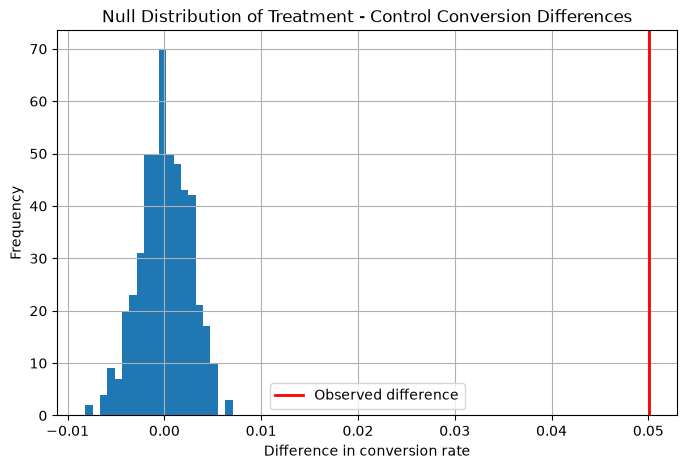

In [90]:
pd.Series(p_diffs).hist(bins=20, figsize=(8, 5))
plt.axvline(observed_diff, color='red', linewidth=2, label='Observed difference')
plt.title('Null Distribution of Treatment - Control Conversion Differences')
plt.xlabel('Difference in conversion rate')
plt.ylabel('Frequency')
plt.legend()
plt.show()

`g)` What proportion of the **p_diffs** are greater than the difference observed between `treatment` and `control` in `df`?

In [91]:
simulated_p_value = (p_diffs > observed_diff).mean()
simulated_p_value

np.float64(0.0)

`h)` In words, explain what you just computed in part `g)`  What is this value called in scientific studies?  What does this value mean in terms of whether or not there is a difference between the new and old pages using our Type I error rate of 0.05?

The proportion computed in part `g)` is the **p-value** from the one-sided hypothesis test. It measures how often we would observe a treatment-minus-control difference at least as large as the one in the data if the null hypothesis were true and the two pages actually had the same conversion rate.

Here, the simulated p-value is effectively `0.0` because none of the 500 null differences were as large as the observed difference of about `0.0501`. Statistically, that is far below the Type I error rate of `0.05`, so we reject the null hypothesis and conclude the treatment page converts better than the control page.

Practically, the improvement is also meaningful: the treatment page raises the observed conversion rate from about `10.53%` to `15.53%`, which is an increase of roughly `5` percentage points.

#### Part III - A/B Test Cross-Check
To make the statistical interpretation explicit, the next two cells compute the one-sided z-test test statistic and p-value analytically in addition to the simulation above.

In [92]:
x_treatment = df.query('group == "treatment"')['converted'].sum()
x_control = df.query('group == "control"')['converted'].sum()
z_statistic, analytic_p_value = one_sided_z_test(observed_diff, x_treatment, x_control, n_treatment, n_control)
print(f'Observed difference: {observed_diff:.6f}')
print(f'Z-statistic: {z_statistic:.6f}')
print(f'Analytic one-sided p-value: {analytic_p_value:.6f}')

Observed difference: 0.050067
Z-statistic: 19.647243
Analytic one-sided p-value: 0.000000


The **test statistic** is the standardized observed lift in conversion rate: how many standard errors the treatment result is above the null expectation of no difference. A z-statistic near `19.65` is extremely large, so the treatment result is far from what the null hypothesis would predict.

The **p-value** is effectively `0.0`, which means the observed lift would be extraordinarily unlikely if the old and new pages truly performed the same. Both the simulation and the analytic z-test therefore support the same decision: reject the null hypothesis and favor the treatment page.

#### Standout Extension 1 - Expanded EDA
This section adds one more view of the experiment by comparing conversion rates across both group and country at the same time.

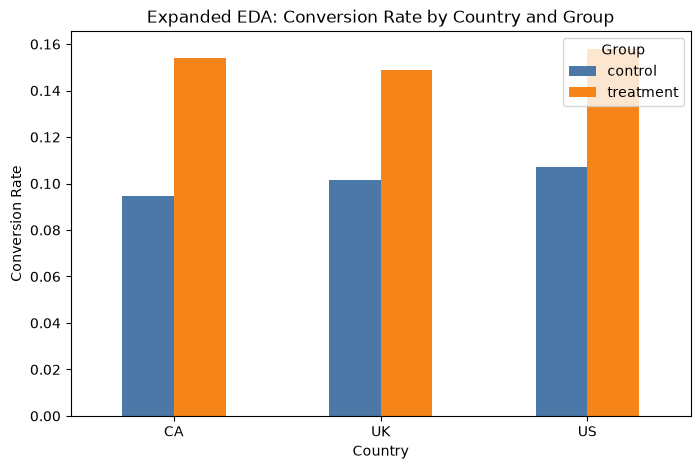

In [93]:
country_group_conversion = df.groupby(['country', 'group'])['converted'].mean().unstack()
country_group_conversion.plot(kind='bar', figsize=(8, 5), color=['#4C78A8', '#F58518'])
plt.title('Expanded EDA: Conversion Rate by Country and Group')
plt.ylabel('Conversion Rate')
plt.xlabel('Country')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.show()

The treatment page outperforms the control page in all three countries. That pattern suggests the treatment effect is broad rather than driven by a single country, and it weakens the concern that country alone is causing the observed lift.

#### Standout Extension 2 - Logistic Regression Confounding Check
A simple logistic-regression model checks whether the treatment effect remains positive after controlling for country.

In [94]:
model_df = df.copy()
model_df['is_treatment'] = (model_df['group'] == 'treatment').astype(int)
X = pd.get_dummies(model_df[['is_treatment', 'country']], drop_first=True)
y = model_df['converted']
logit_model = LogisticRegression(max_iter=1000, random_state=0)
logit_model.fit(X, y)
predicted_probabilities = logit_model.predict_proba(X)[:, 1]
logit_summary = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logit_model.coef_[0],
    'odds_ratio': np.exp(logit_model.coef_[0])
}).sort_values('odds_ratio', ascending=False)
print(f'ROC AUC: {roc_auc_score(y, predicted_probabilities):.4f}')
logit_summary

ROC AUC: 0.5587


,feature,coefficient,odds_ratio
0,is_treatment,0.446493,1.562822
2,country_US,0.074068,1.076880
1,country_UK,0.007966,1.007998


The treatment indicator remains the strongest predictor in the logistic model, with an odds ratio around `1.56`. The country coefficients are much smaller, so there is little evidence that country is a major confounder that explains away the treatment effect.

## Slide-Ready Summary
- **Descriptive takeaway:** the dataset contains `69,889` visits, no missing values, and a binary conversion outcome.
- **Probability takeaway:** treatment users convert more often than control users, and the treatment advantage appears in every country shown.
- **Experiment takeaway:** both the simulation and the z-test produce an essentially zero p-value, so the treatment page is statistically and practically better than the control page.

<a id='finalcheck'></a>
## Final Check!

Congratulations!  You have reached the end of the A/B Test Results project!  You should be very proud of all you have accomplished!

> **Tip**: Once you are satisfied with your work here, check over your notebook to make sure that it satisfies all the specifications mentioned in the rubric. You should also probably remove all of the "Hints" and "Tips" like this one so that the presentation is as polished as possible.


<a id='submission'></a>
## Submission

Please follow the directions in the classroom to submit this notebook, as well as your completed slides.